<a href="https://colab.research.google.com/github/emaudealtema/Computer_vision_repo/blob/main/Modele_Resnet101_avec_Fastai_version2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from fastai.callback.all import *
from fastai.vision.all import *
from fastai.callback.all import CSVLogger, SaveModelCallback
#from torchvision.models import efficientnet_b0

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd
import numpy as np
import warnings

In [4]:
%matplotlib inline

In [5]:
#!wget https://www.dropbox.com/s/u83ae1efaah2w9o/UCMercedLanduse.zip
#!unzip UCMercedLanduse.zip


In [6]:
df = pd.read_csv("/content/drive/MyDrive/UCMerced/multilabels.txt", sep="\t")
df.head(10)

,IMAGE\LABEL,airplane,bare-soil,buildings,cars,chaparral,court,dock,field,grass,mobile-home,pavement,sand,sea,ship,tanks,trees,water
0,agricultural00,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
1,agricultural01,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,agricultural02,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,agricultural03,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,agricultural04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
5,agricultural05,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
6,agricultural06,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
7,agricultural07,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
8,agricultural08,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
9,agricultural09,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [7]:
df.shape

(2100, 18)

In [8]:
class_count = pd.DataFrame(df.sum(axis=0)).reset_index()
class_count.columns = ["class", "Count"]
class_count.drop(class_count.index[0], inplace=True)
class_count

,class,Count
1,airplane,100
2,bare-soil,718
3,buildings,691
4,cars,886
5,chaparral,115
6,court,105
7,dock,100
8,field,103
9,grass,975
10,mobile-home,102


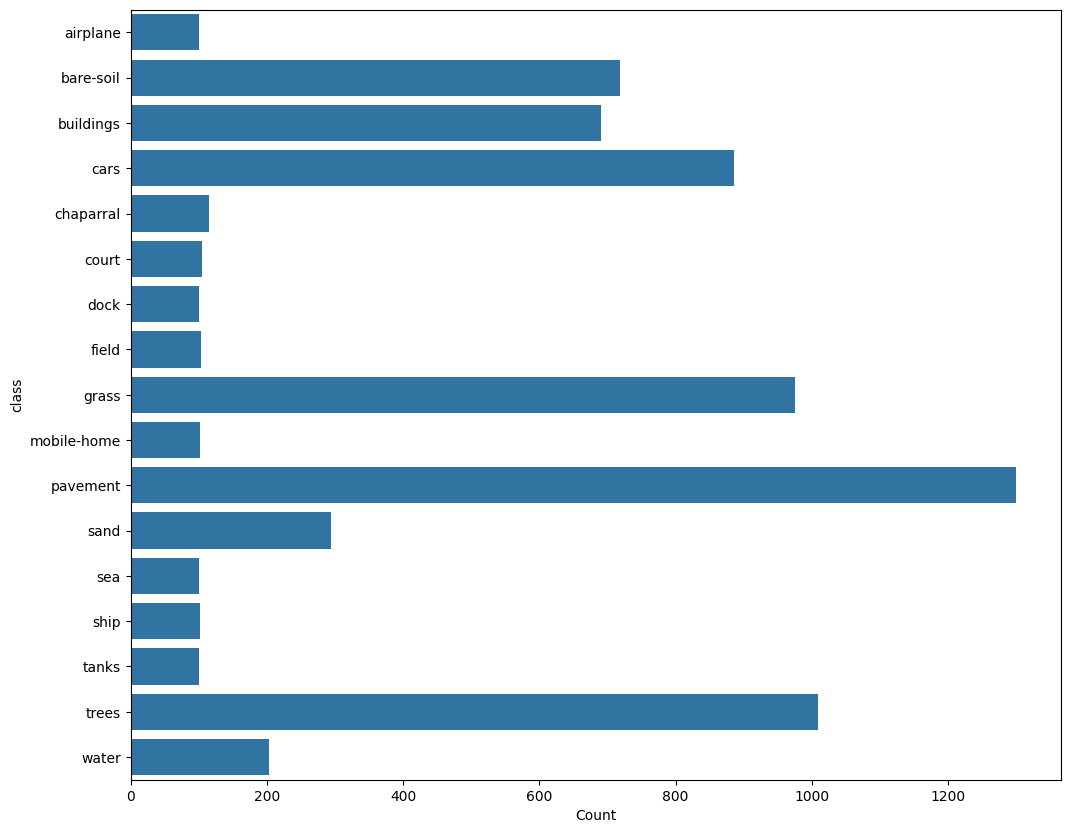

In [9]:
fig, ax= plt.subplots(figsize=(12,10))
sns.barplot(y="class", x="Count",  data=class_count, ax=ax);

In [10]:
list(class_count['class'])

['airplane',
 'bare-soil',
 'buildings',
 'cars',
 'chaparral',
 'court',
 'dock',
 'field',
 'grass',
 'mobile-home',
 'pavement',
 'sand',
 'sea',
 'ship',
 'tanks',
 'trees',
 'water']

In [11]:
from pathlib import Path

path = Path("/content/drive/MyDrive/UCMerced")

print("Niveau 1 :", path.ls())

for p in path.ls():
    if p.is_dir():
        print(f"\nContenu de {p} :", p.ls()[:5])

Niveau 1 : [Path('/content/drive/MyDrive/UCMerced/Images'), Path('/content/drive/MyDrive/UCMerced/multilabels.txt')]

Contenu de /content/drive/MyDrive/UCMerced/Images : [Path('/content/drive/MyDrive/UCMerced/Images/tenniscourt'), Path('/content/drive/MyDrive/UCMerced/Images/storagetanks'), Path('/content/drive/MyDrive/UCMerced/Images/runway'), Path('/content/drive/MyDrive/UCMerced/Images/river'), Path('/content/drive/MyDrive/UCMerced/Images/sparseresidential')]


In [12]:
from fastai.vision.all import *
import re

path = Path("/content/drive/MyDrive/UCMerced/Images")  # 🔥 on pointe directement vers images

# Fonction pour extraire le label
def get_label(x):
    return re.match(r"[a-zA-Z]+", x.stem).group()

# DataBlock corrigé
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_label,   # 🔥 ici la correction clé
    item_tfms=Resize(256),
    batch_tfms=aug_transforms(
        flip_vert=True,
        max_lighting=0.1,
        max_zoom=1.05,
        max_warp=0.)
)



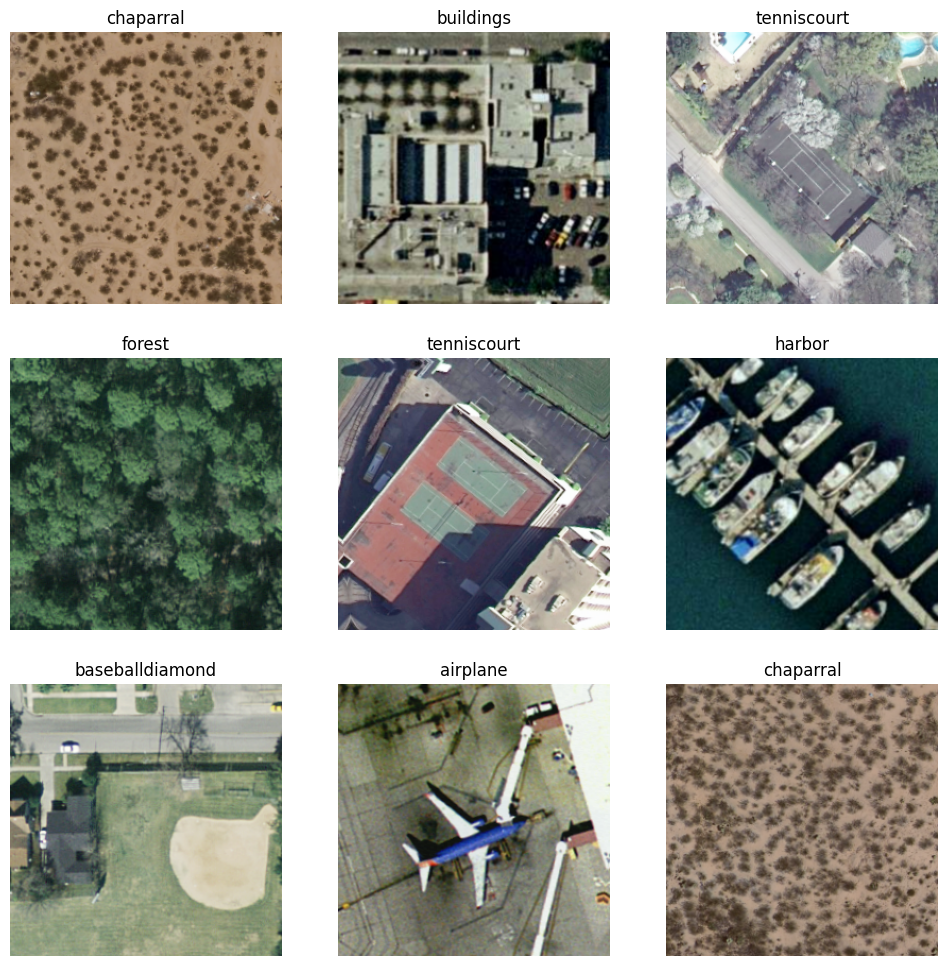

In [13]:
# DataLoaders
dls = dblock.dataloaders(path, bs=32)

# Vérification du batch
dls.show_batch(max_n=9, figsize=(12,12))




In [14]:

print(f"\nNombre total de classes : {len(dls.vocab)}")


Nombre total de classes : 21


In [15]:
from fastai.vision.all import *
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

path = Path("/content/drive/MyDrive/UCMerced/Images")

# =========================
# 1. SPLITTER 3 SETS
# =========================
def splitter_func(items):
    train_idx, temp_idx = RandomSplitter(valid_pct=0.3, seed=42)(items)
    val_idx, test_idx = RandomSplitter(valid_pct=0.5, seed=42)([items[i] for i in temp_idx])

    # correction des index
    val_idx = [temp_idx[i] for i in val_idx]
    test_idx = [temp_idx[i] for i in test_idx]

    return train_idx, val_idx, test_idx

In [16]:
# =========================
# construire les DATABLOCK
# =========================
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=splitter_func,
    get_y=parent_label,  # ⚠️ plus robuste que get_label si dossier = classe
    item_tfms=Resize(256),
    batch_tfms=[*aug_transforms(
        flip_vert=True,
        max_rotate=20,
        max_zoom=1.2,
        max_lighting=0.2,
        max_warp=0.1
    ), Normalize.from_stats(*imagenet_stats)]
)

In [17]:
# =========================
# Construire les DATALOADERS
# =========================
dls = dblock.dataloaders(path, bs=32)

print(dls.vocab)  # classes

# =========================
# 4. MODELE ResNet101
# =========================
learn = cnn_learner(
    dls,
    resnet101,
    metrics=accuracy
)


['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:00<00:00, 265MB/s]


In [18]:
print(len(dls.train_ds))
print(len(dls.valid_ds))

1470
315


In [19]:
print(dls.vocab)

['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


<div></div>

SuggestedLRs(valley=0.0010000000474974513)

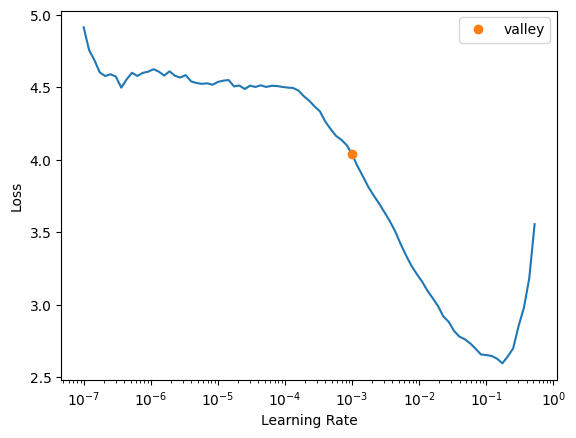

In [ ]:
learn.lr_find()

In [20]:
# =========================
# 5. TRAINING
# =========================
learn.fine_tune(50, base_lr=1e-2)

# sauvegarde
learn.save("resnet101_model")



epoch,train_loss,valid_loss,accuracy,time
0,1.496429,0.685305,0.806349,03:39


epoch,train_loss,valid_loss,accuracy,time
0,0.450664,0.236022,0.895238,00:33
1,0.306010,0.098530,0.971429,00:34
2,0.203798,0.091858,0.968254,00:33
3,0.163947,0.075283,0.974603,00:33
4,0.123698,0.161909,0.961905,00:33
5,0.111937,0.202120,0.952381,00:33
6,0.152649,0.210307,0.949206,00:33
7,0.167006,0.270146,0.926984,00:33
8,0.194356,0.223570,0.936508,00:33
9,0.176050,0.232683,0.958730,00:33


epoch,train_loss,valid_loss,accuracy,time
0,0.450664,0.236022,0.895238,00:33
1,0.306010,0.098530,0.971429,00:34
2,0.203798,0.091858,0.968254,00:33
3,0.163947,0.075283,0.974603,00:33
4,0.123698,0.161909,0.961905,00:33
5,0.111937,0.202120,0.952381,00:33
6,0.152649,0.210307,0.949206,00:33
7,0.167006,0.270146,0.926984,00:33
8,0.194356,0.223570,0.936508,00:33
9,0.176050,0.232683,0.958730,00:33


Path('models/resnet101_model.pth')

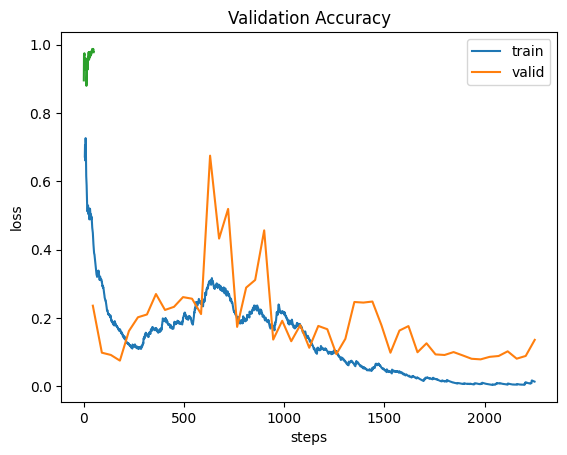

In [22]:
# =========================
# 6. GRAPHES
# =========================
learn.recorder.plot_loss()

# accuracy
plt.plot([x[2] for x in learn.recorder.values])
plt.title("Validation Accuracy")
plt.show()

In [24]:
# Sauvegarder le modele REsnet101
learn.export("resnet101_ucmerced.pkl")

In [25]:
# POur pouvoir le recharger plus tard
learn_inf = load_learner("resnet101_ucmerced.pkl")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [42]:
# On definit cette fonction pour reccuperer le test set
def splitter_func(items):
    train_idx, temp_idx = RandomSplitter(valid_pct=0.3, seed=42)(items)
    val_idx, test_idx = RandomSplitter(valid_pct=0.5, seed=42)([items[i] for i in temp_idx])

    # correction des index
    val_idx = [temp_idx[i] for i in val_idx]
    test_idx = [temp_idx[i] for i in test_idx]

    return train_idx, val_idx, test_idx


In [47]:
#test_items est probablement vide
#ou dls.test_dl(test_items) n’a rien à charger
#du coup learn.get_preds(dl=test_dl) retourne None

print(len(test_items))
print(test_items[:5])

220
[Path('/content/drive/MyDrive/UCMerced/Images/sparseresidential/sparseresidential54.tif'), Path('/content/drive/MyDrive/UCMerced/Images/harbor/harbor23.tif'), Path('/content/drive/MyDrive/UCMerced/Images/river/river99.tif'), Path('/content/drive/MyDrive/UCMerced/Images/freeway/freeway73.tif'), Path('/content/drive/MyDrive/UCMerced/Images/mediumresidential/mediumresidential06.tif')]


In [55]:
from fastai.vision.all import *
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1️⃣ Récupérer les indices du test set
_, _, test_idx = splitter_func(dls.items)



In [72]:
# 2️⃣ Récupérer les fichiers correspondants
test_items = [dls.items[i] for i in test_idx]
print(f"Nombre d'images test : {len(test_items)}")
print(test_items[:6])

# 3️⃣ Créer le DataLoader pour le test set
test_dl = dls.test_dl(test_items, with_labels=True)

Nombre d'images test : 220
[Path('/content/drive/MyDrive/UCMerced/Images/sparseresidential/sparseresidential54.tif'), Path('/content/drive/MyDrive/UCMerced/Images/harbor/harbor23.tif'), Path('/content/drive/MyDrive/UCMerced/Images/river/river99.tif'), Path('/content/drive/MyDrive/UCMerced/Images/freeway/freeway73.tif'), Path('/content/drive/MyDrive/UCMerced/Images/mediumresidential/mediumresidential06.tif'), Path('/content/drive/MyDrive/UCMerced/Images/beach/beach46.tif')]


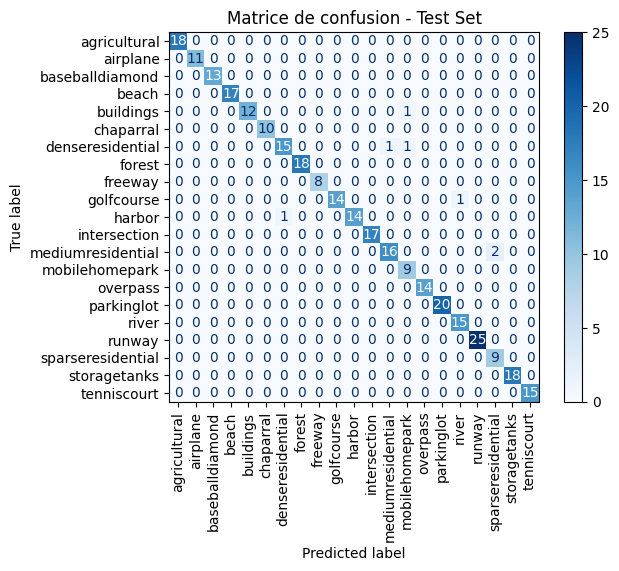

In [58]:
# 6️⃣ Matrice de confusion
cm = confusion_matrix(targs, preds.argmax(dim=1))
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(xticks_rotation=90, cmap=plt.cm.Blues)
plt.title("Matrice de confusion - Test Set")
plt.show()

<Axes: >

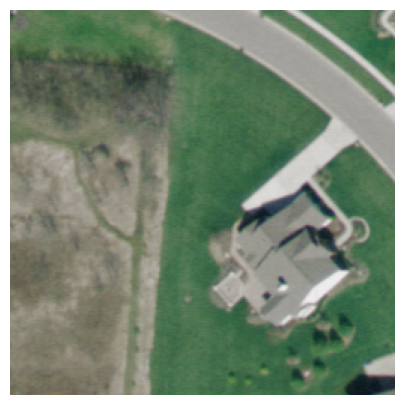

In [59]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/sparseresidential/sparseresidential54.tif")
img.show()

In [61]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'sparseresidential'

<Axes: >

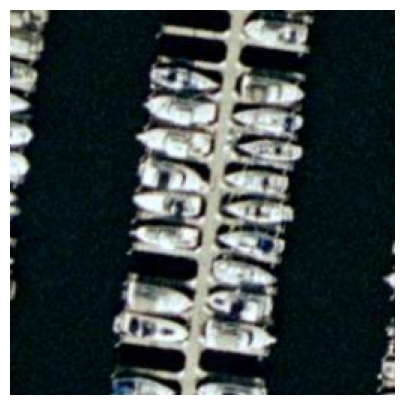

In [64]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/harbor/harbor23.tif")
img.show()

In [65]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'airplane'

<Axes: >

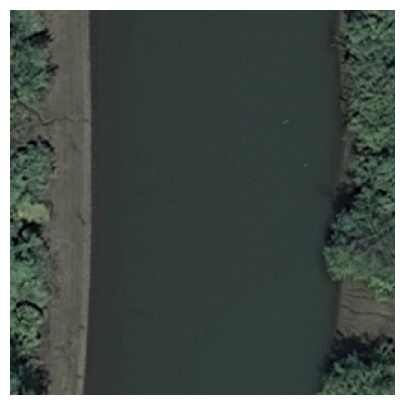

In [66]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/river/river99.tif")
img.show()

In [67]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'river'

<Axes: >

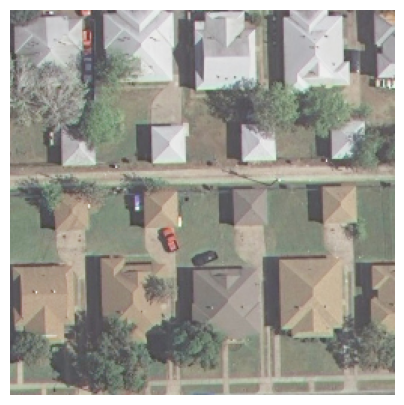

In [68]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/mediumresidential/mediumresidential06.tif")
img.show()

In [69]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'mediumresidential'

<Axes: >

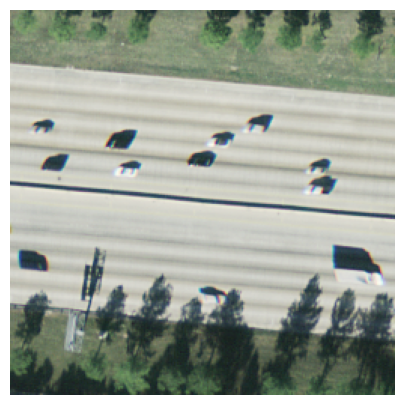

In [70]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/freeway/freeway73.tif")
img.show()

In [71]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'freeway'

<Axes: >

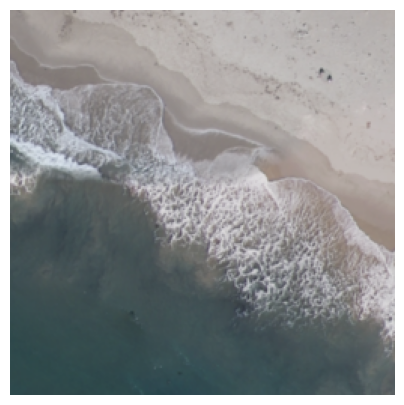

In [74]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/beach/beach46.tif")
img.show()

In [75]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'beach'

<Axes: >

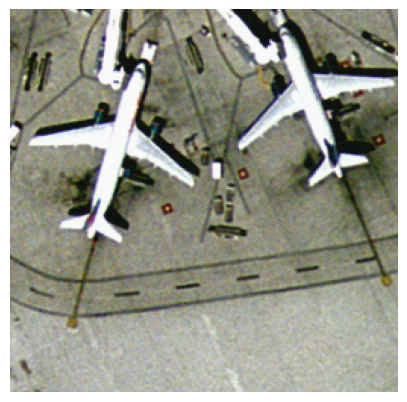

In [77]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/airplane/airplane59.tif")
img.show()

In [78]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'airplane'

<Axes: >

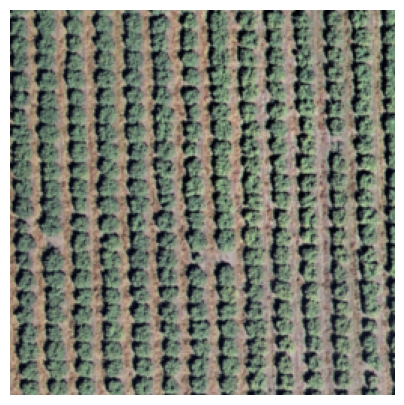

In [79]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/agricultural/agricultural22.tif")
img.show()

In [80]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'agricultural'

<Axes: >

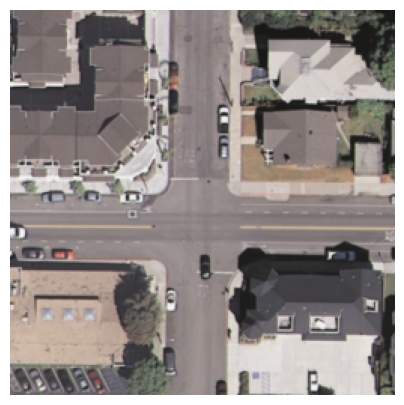

In [81]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/intersection/intersection98.tif")
img.show()

In [82]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'intersection'

<Axes: >

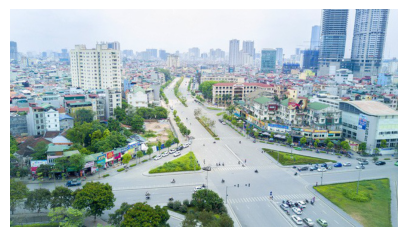

In [83]:
img = PILImage.create("/content/drive/MyDrive/Dossier sans titre/cau giay.png")
img.show()

In [84]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'intersection'

<Axes: >

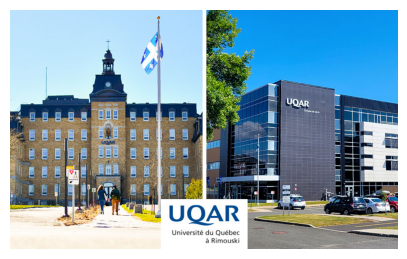

In [85]:
img = PILImage.create("/content/drive/MyDrive/Dossier sans titre/uqar_rimouskilevis.jpg")
img.show()

In [86]:
pred_class,pred_idx,outputs = learn.predict(img)
pred_class

'buildings'